# EDA — Structured Features vs. ESG Scores

Explores the relationship between company size (`log_total_assets`) and ESG scores.
Primary hypothesis: larger companies have dedicated ESG teams and report more comprehensively,
placing them in the upper mode of the bimodal score distribution.

`log_total_assets` is used as the company size proxy — best coverage (99%) and most standard
balance-sheet measure of firm scale.

**Requires:** `data/structured_features/sec_fundamentals.csv` (run `structured_features_collection.ipynb` first).

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from pathlib import Path

DATA_DIR = Path('../data')

SCORE_COLS = ['environment_score', 'social_score', 'governance_score', 'total_score']
COLORS     = ['#2ecc71', '#3498db', '#9b59b6', '#e74c3c']

## 1. Load and merge data

In [ ]:
fundamentals = pd.read_csv(DATA_DIR / 'structured_features' / 'sec_fundamentals.csv')
fundamentals['ticker'] = fundamentals['ticker'].str.upper()

labels = pd.read_csv(DATA_DIR / 'finbert_features' / 'merged_features_labels.csv')
labels['ticker'] = labels['ticker'].str.upper()

df = fundamentals.merge(
    labels[['ticker'] + SCORE_COLS],
    on='ticker', how='inner'
)

SIZE_COL   = 'log_total_assets'
SIZE_LABEL = 'Log Total Assets (USD)'

print(f'Dataset: {len(df)} companies')
print(f'Size proxy: {SIZE_COL}  ({df[SIZE_COL].notna().sum()} non-null)')
df[SCORE_COLS + [SIZE_COL]].describe()

## 2. Score vs. Company Size — Scatter Plots

Each panel shows one ESG pillar. The regression line and Pearson r / p-value test whether
larger companies systematically score higher — the central company-size hypothesis.

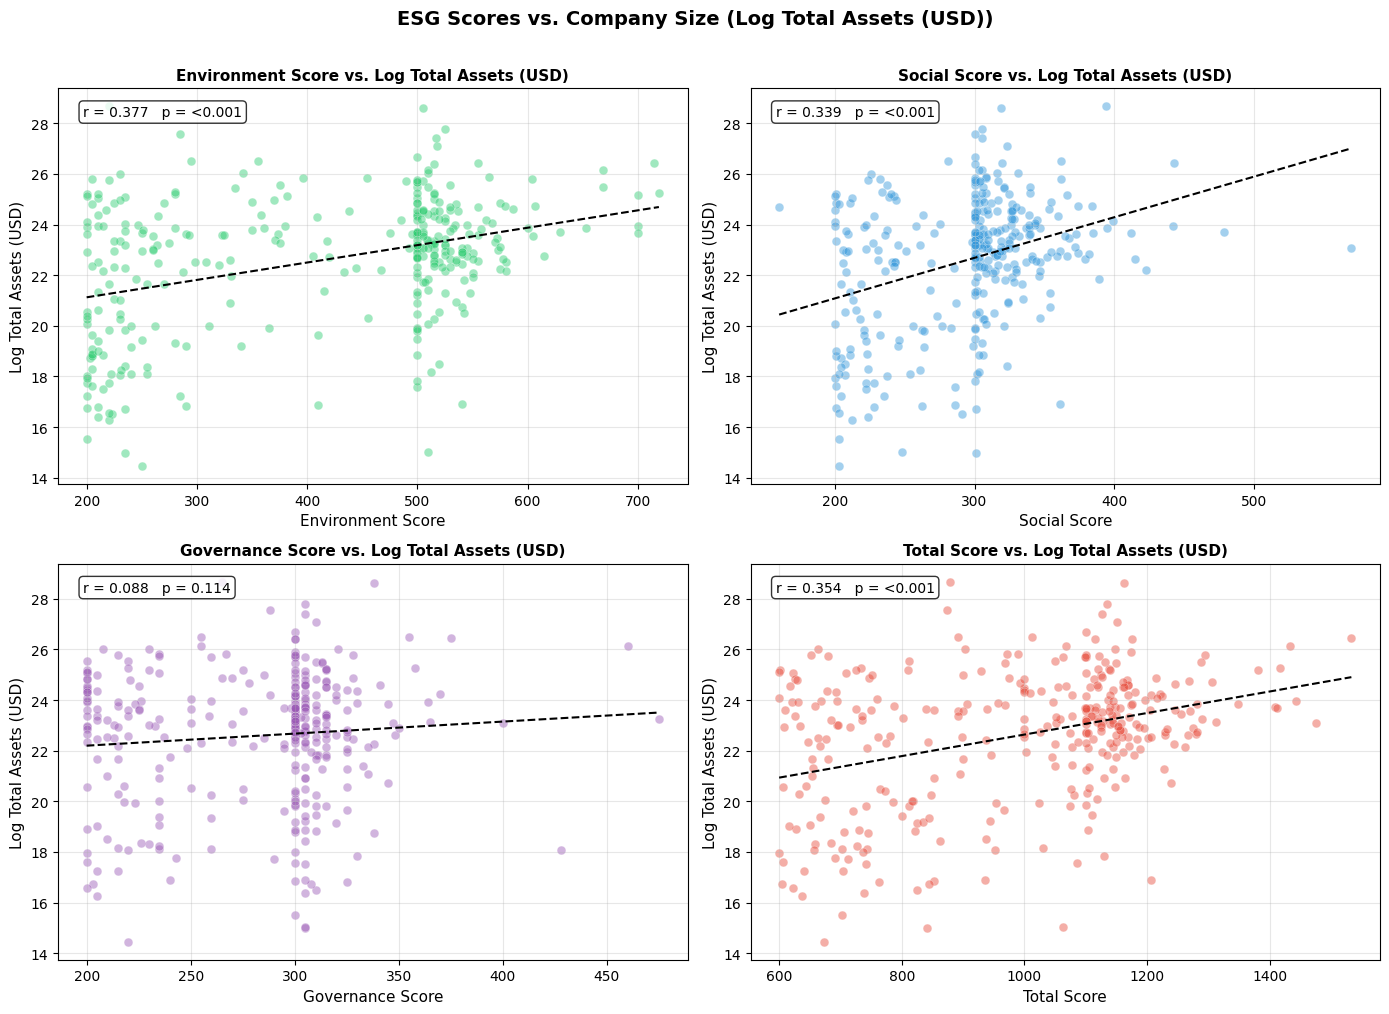

In [4]:
def plot_score_vs_size(df, size_col, size_label):
    """2x2 scatter plots: ESG score (x) vs company size (y) with regression line."""
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    for ax, score_col, color in zip(axes.flatten(), SCORE_COLS, COLORS):
        plot_df = df[[score_col, size_col]].dropna()
        x = plot_df[score_col].values
        y = plot_df[size_col].values

        # Scatter
        ax.scatter(x, y, alpha=0.45, color=color, edgecolors='white', linewidths=0.4, s=40)

        # Regression line
        slope, intercept, r, p, _ = stats.linregress(x, y)
        x_line = np.linspace(x.min(), x.max(), 200)
        ax.plot(x_line, slope * x_line + intercept, color='black', linewidth=1.5, linestyle='--')

        # Annotation
        p_str = f'{p:.3f}' if p >= 0.001 else '<0.001'
        ax.text(0.04, 0.93, f'r = {r:.3f}   p = {p_str}',
                transform=ax.transAxes, fontsize=10,
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

        ax.set_xlabel(score_col.replace('_', ' ').title(), fontsize=11)
        ax.set_ylabel(size_label, fontsize=11)
        ax.set_title(f'{score_col.replace("_", " ").title()} vs. {size_label}',
                     fontsize=11, fontweight='bold')
        ax.grid(True, alpha=0.3)

    plt.suptitle(f'ESG Scores vs. Company Size ({size_label})',
                 fontsize=14, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()

plot_score_vs_size(df, SIZE_COL, SIZE_LABEL)

## 3. Score Distribution by Size Quartile

Companies are split into four equal-sized bins by company size (Q1 = smallest, Q4 = largest).
Box plots show whether the ESG score distribution shifts upward as company size increases —
the expected pattern if size drives the upper mode of the bimodal distribution.

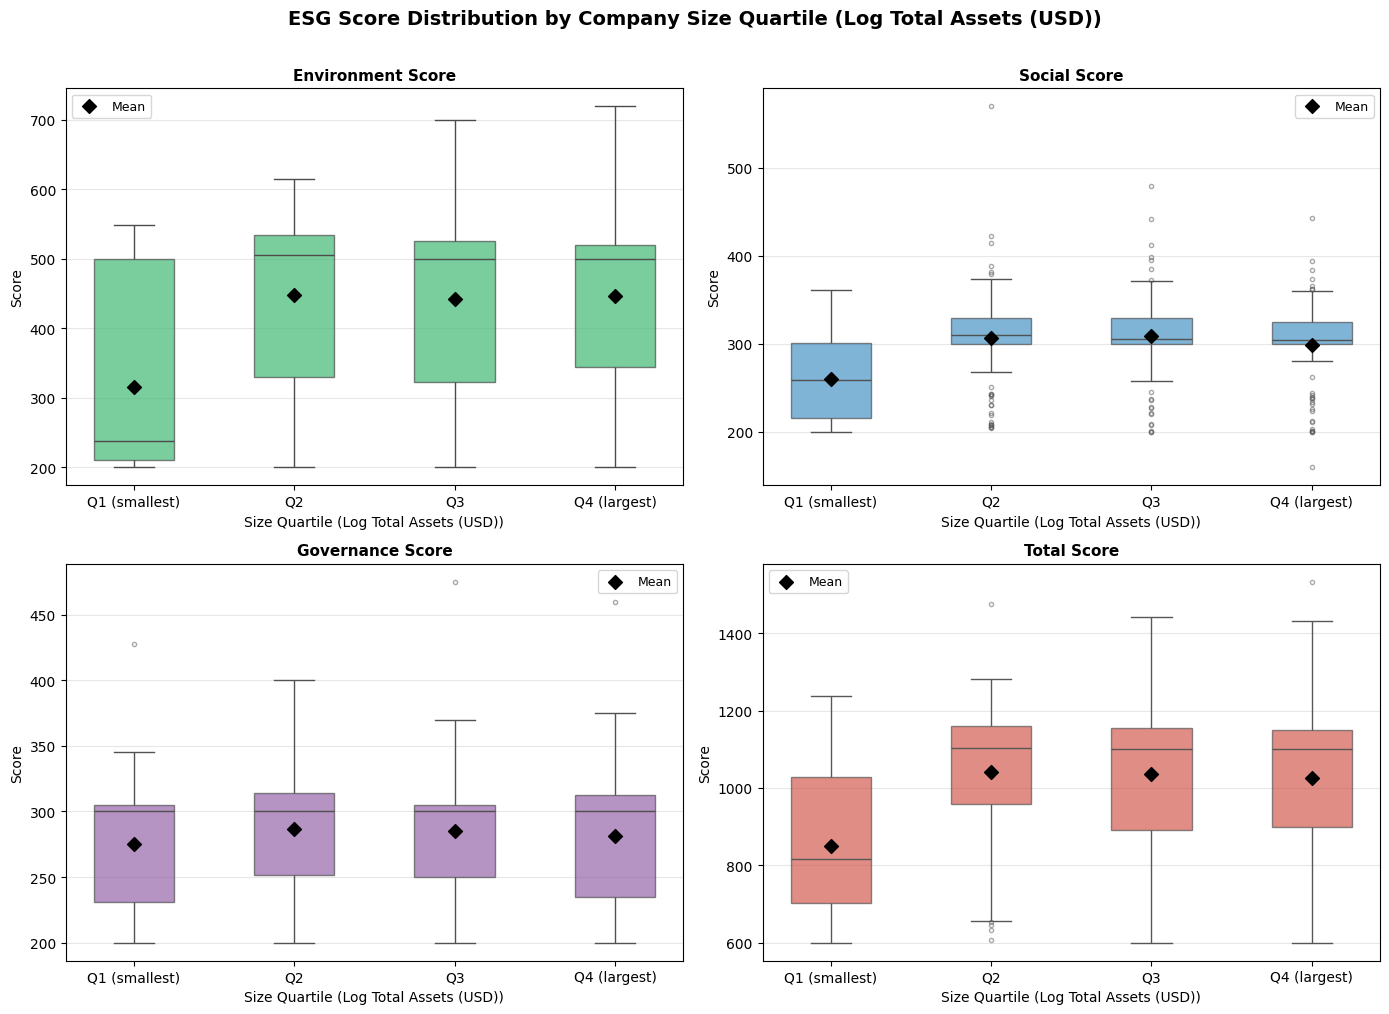

Mean ESG scores by size quartile:
               environment_score  social_score  governance_score  total_score
size_quartile                                                                
Q1 (smallest)              315.0         260.4             274.9        850.3
Q2                         447.6         307.2             286.3       1041.1
Q3                         442.1         308.8             284.8       1035.7
Q4 (largest)               446.2         299.2             280.9       1026.3


In [5]:
def plot_score_by_size_quartile(df, size_col, size_label):
    """Box plots of ESG score distributions split by size quartile."""
    plot_df = df[SCORE_COLS + [size_col]].dropna(subset=[size_col]).copy()
    plot_df['size_quartile'] = pd.qcut(
        plot_df[size_col], q=4,
        labels=['Q1 (smallest)', 'Q2', 'Q3', 'Q4 (largest)']
    )

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    for ax, score_col, color in zip(axes.flatten(), SCORE_COLS, COLORS):
        sns.boxplot(
            data=plot_df, x='size_quartile', y=score_col,
            color=color, ax=ax, width=0.5,
            boxprops=dict(alpha=0.7),
            flierprops=dict(marker='o', markersize=3, alpha=0.5)
        )
        # Overlay group means
        means = plot_df.groupby('size_quartile')[score_col].mean()
        ax.scatter(range(len(means)), means.values,
                   color='black', zorder=5, s=50, marker='D', label='Mean')
        ax.legend(fontsize=9)

        ax.set_title(score_col.replace('_', ' ').title(), fontsize=11, fontweight='bold')
        ax.set_xlabel(f'Size Quartile ({size_label})', fontsize=10)
        ax.set_ylabel('Score', fontsize=10)
        ax.grid(True, axis='y', alpha=0.3)

    plt.suptitle(f'ESG Score Distribution by Company Size Quartile ({size_label})',
                 fontsize=14, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()

    # Print mean scores per quartile for each pillar
    print('Mean ESG scores by size quartile:')
    print(plot_df.groupby('size_quartile')[SCORE_COLS].mean().round(1).to_string())

plot_score_by_size_quartile(df, SIZE_COL, SIZE_LABEL)

## 4. Bimodal Threshold vs. Company Size

The environment score distribution is bimodal with a threshold near 500.
This plot tests whether the above/below-500 split aligns with company size —
the key test of the selective-disclosure hypothesis.

C:\Users\Caden\AppData\Local\Temp\ipykernel_34200\1989426139.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\Caden\AppData\Local\Temp\ipykernel_34200\1989426139.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(


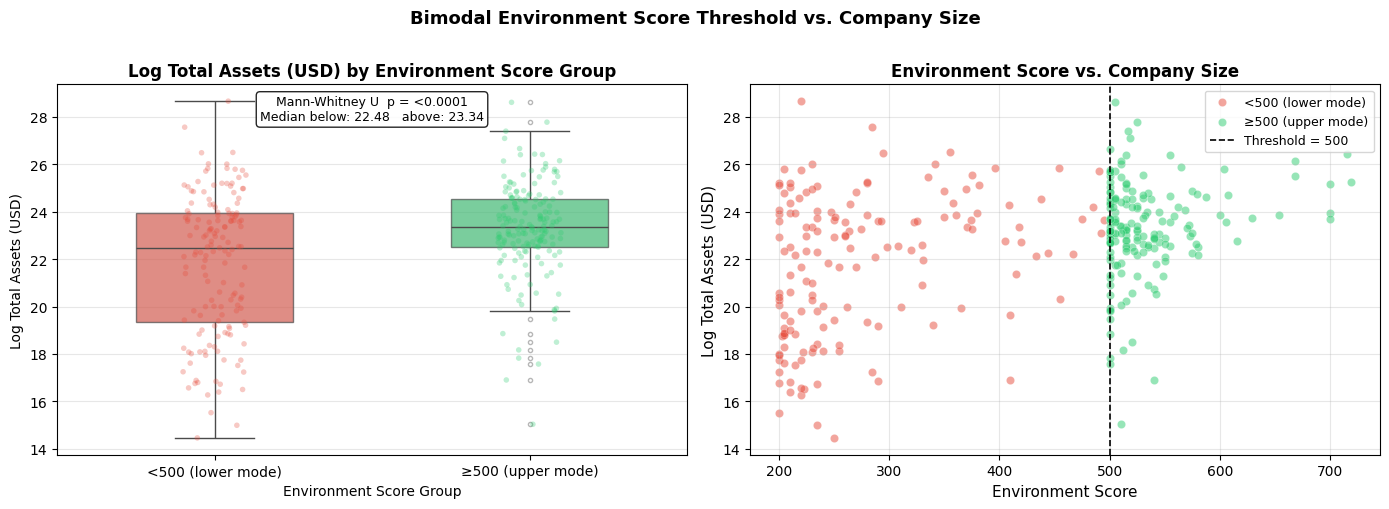

In [6]:
def plot_threshold_vs_size(df, size_col, size_label, threshold=500):
    """Box + strip plots comparing company size above/below the ESG environment threshold."""
    plot_df = df[['environment_score', size_col]].dropna().copy()
    plot_df['above_threshold'] = plot_df['environment_score'].apply(
        lambda s: f'≥{threshold} (upper mode)' if s >= threshold else f'<{threshold} (lower mode)'
    )

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Left: box plot
    order = [f'<{threshold} (lower mode)', f'≥{threshold} (upper mode)']
    sns.boxplot(
        data=plot_df, x='above_threshold', y=size_col,
        order=order, palette=['#e74c3c', '#2ecc71'],
        ax=axes[0], width=0.5,
        boxprops=dict(alpha=0.7),
        flierprops=dict(marker='o', markersize=3, alpha=0.4)
    )
    sns.stripplot(
        data=plot_df, x='above_threshold', y=size_col,
        order=order, palette=['#e74c3c', '#2ecc71'],
        ax=axes[0], alpha=0.3, size=4, jitter=True
    )
    axes[0].set_title(f'{size_label} by Environment Score Group', fontweight='bold')
    axes[0].set_xlabel('Environment Score Group')
    axes[0].set_ylabel(size_label)
    axes[0].grid(True, axis='y', alpha=0.3)

    # Mann-Whitney U test
    below = plot_df.loc[plot_df['above_threshold'].str.startswith('<'), size_col]
    above = plot_df.loc[plot_df['above_threshold'].str.startswith('≥'), size_col]
    stat, p = stats.mannwhitneyu(above, below, alternative='greater')
    p_str = f'{p:.4f}' if p >= 0.0001 else '<0.0001'
    axes[0].text(0.5, 0.97,
        f'Mann-Whitney U  p = {p_str}\n'
        f'Median below: {below.median():.2f}   above: {above.median():.2f}',
        transform=axes[0].transAxes, ha='center', va='top', fontsize=9,
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.85))

    # Right: scatter — environment_score (x) vs size (y), coloured by group
    colors_map = {f'<{threshold} (lower mode)': '#e74c3c',
                  f'≥{threshold} (upper mode)': '#2ecc71'}
    for group, grp_df in plot_df.groupby('above_threshold'):
        axes[1].scatter(
            grp_df['environment_score'], grp_df[size_col],
            label=group, alpha=0.5, s=35,
            color=colors_map[group], edgecolors='white', linewidths=0.3
        )
    axes[1].axvline(threshold, color='black', linestyle='--', linewidth=1.2,
                    label=f'Threshold = {threshold}')
    axes[1].set_xlabel('Environment Score', fontsize=11)
    axes[1].set_ylabel(size_label, fontsize=11)
    axes[1].set_title('Environment Score vs. Company Size', fontweight='bold')
    axes[1].legend(fontsize=9)
    axes[1].grid(True, alpha=0.3)

    plt.suptitle('Bimodal Environment Score Threshold vs. Company Size',
                 fontsize=13, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()

plot_threshold_vs_size(df, SIZE_COL, SIZE_LABEL)